In [1]:
# ¿Cómo podemos predecir el consumo de combustible (MPG) de un automóvil a partir de sus características técnicas?

import pandas as pd

dataset = pd.read_csv("../data/auto_mpg.csv")
dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [2]:
# Tamaño del dataset
dataset.shape

(398, 8)

In [3]:
# Búsqueda de valores nulos

dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [4]:
# Remoción de valores nulos

dataset = dataset.dropna()
dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [5]:
# Columna Origin
# Nota:  1) USA
#        2) Europe
#        3) Japan

dataset.Origin.value_counts()

Origin
1    245
3     79
2     68
Name: count, dtype: int64

In [6]:
# Convierte la columna a categorias.
# Nota. Realmente no se debería hacer asi para aplicaciones
# en productivo

dataset["Origin"] = dataset["Origin"].map(
    {1: "USA", 2: "Europe", 3: "Japan"},
)

In [7]:
# Se debe conservar la categoría de origen para codificarla después de separar entrenamiento y prueba.

dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,USA
1,15.0,8,350.0,165.0,3693.0,11.5,70,USA
2,18.0,8,318.0,150.0,3436.0,11.0,70,USA
3,16.0,8,304.0,150.0,3433.0,12.0,70,USA
4,17.0,8,302.0,140.0,3449.0,10.5,70,USA


In [8]:
# Se deben separar vehículos para entrenamiento y prueba con una partición reproducible.

from sklearn.model_selection import train_test_split

train_dataset, test_dataset = train_test_split(
    dataset,
    train_size=0.8,
    random_state=0,
)

/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_in

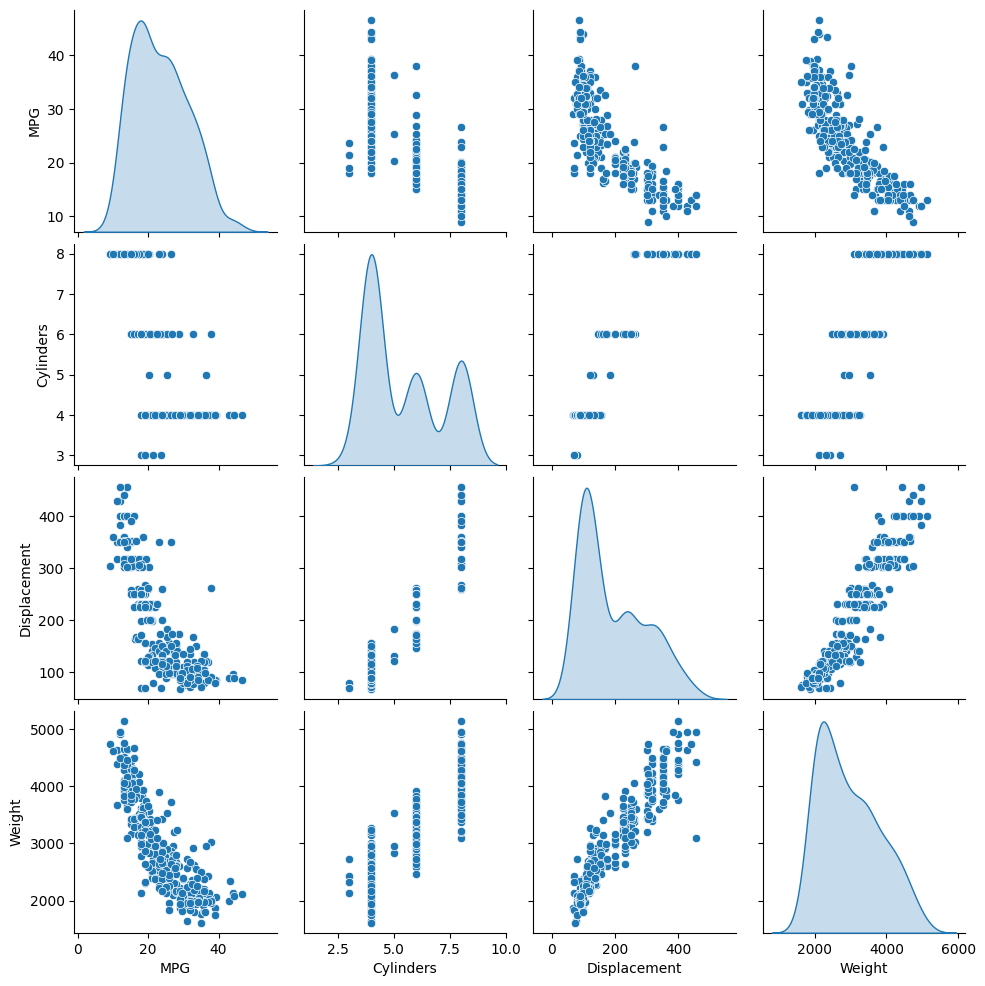

In [9]:
# Las millas por galon (MPG) son función de las demas variables.

import seaborn as sns

sns.pairplot(
    train_dataset[["MPG", "Cylinders", "Displacement", "Weight"]], diag_kind="kde"
)

In [10]:
# Cálculo de algunas estadísticas generales

train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,313.0,23.482428,7.784488,9.0,17.5,23.0,29.0,46.6
Cylinders,313.0,5.447284,1.690263,3.0,4.0,4.0,8.0,8.0
Displacement,313.0,192.787540,103.201153,68.0,105.0,151.0,260.0,455.0
Horsepower,313.0,104.009585,37.915348,46.0,78.0,95.0,120.0,230.0
Weight,313.0,2972.255591,841.134947,1613.0,2230.0,2815.0,3574.0,5140.0
Acceleration,313.0,15.560383,2.785476,8.0,13.6,15.5,17.0,24.8
Model Year,313.0,76.070288,3.660449,70.0,73.0,76.0,79.0,82.0


In [11]:
# Particionamiento de los datos en features y labels

train_features = train_dataset.copy()
train_labels = train_features.pop("MPG")

test_features = test_dataset.copy()
test_labels = test_features.pop("MPG")

In [12]:
# Se debe revisar el efecto del escalamiento solo sobre las variables numéricas.

numeric_columns = train_dataset.select_dtypes(include="number").columns

train_dataset[numeric_columns].describe().transpose()[["mean", "std"]]

,mean,std
MPG,23.482428,7.784488
Cylinders,5.447284,1.690263
Displacement,192.787540,103.201153
Horsepower,104.009585,37.915348
Weight,2972.255591,841.134947
Acceleration,15.560383,2.785476
Model Year,76.070288,3.660449


In [13]:
# Se debe observar cómo StandardScaler centra y escala las variables numéricas.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

pd.DataFrame(
    data=scaler.fit_transform(train_dataset[numeric_columns]),
    columns=numeric_columns,
).describe().transpose()[["mean", "std"]]

,mean,std
MPG,5.675261e-18,1.001601
Cylinders,2.553868e-17,1.001601
Displacement,1.418815e-17,1.001601
Horsepower,-1.163429e-16,1.001601
Weight,-2.411986e-16,1.001601
Acceleration,2.447457e-16,1.001601
Model Year,-2.965324e-16,1.001601


In [14]:
# Regresión lineal con una sola variable (Horsepower)

horsepower_scaler = StandardScaler()

train_horsepower = train_features[["Horsepower"]]
test_horsepower = test_features[["Horsepower"]]

horsepower_scaler.fit(train_horsepower)

standarized_train_horsepower = horsepower_scaler.transform(train_horsepower)
standarized_test_horsepower = horsepower_scaler.transform(test_horsepower)

In [15]:
# Modelo de regresión lineal

from sklearn.linear_model import LinearRegression

horsepower_model = LinearRegression()
horsepower_model.fit(standarized_train_horsepower, train_labels)

LinearRegression()

In [16]:
# Intercepto
horsepower_model.intercept_

23.482428115015974

In [17]:
# Coeficientes
horsepower_model.coef_

array([-5.99789514])

In [18]:
# Predicción. Preparación de las variables independientes

import numpy as np

x = pd.DataFrame({"Horsepower": np.linspace(0, 250, 251)})
x.head()

,Horsepower
0,0.0
1,1.0
2,2.0
3,3.0
4,4.0


In [19]:
# Predicción

scaled_x = horsepower_scaler.transform(x)
y = horsepower_model.predict(scaled_x)
y[:5]

array([39.96223258, 39.80378752, 39.64534247, 39.48689741, 39.32845236])

In [20]:
import matplotlib.pyplot as plt


def plot_horsepower(x, y):
    plt.scatter(train_features["Horsepower"], train_labels, label="Data")
    plt.plot(x, y, color="k", label="Predictions")
    plt.xlabel("Horsepower")
    plt.ylabel("MPG")
    plt.legend()

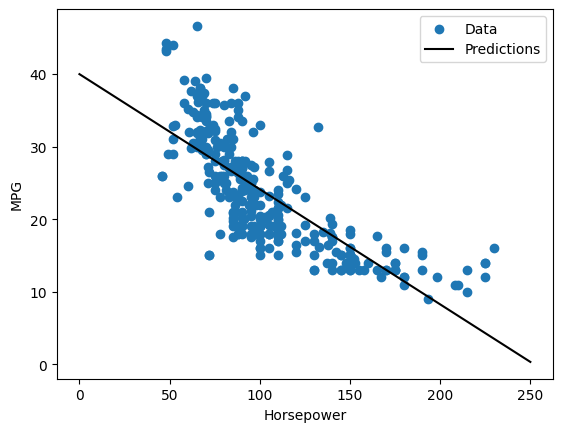

In [21]:
plot_horsepower(x, y)

In [22]:
# Evaluación

from sklearn.metrics import mean_squared_error

test_results = {}

y_pred = horsepower_model.predict(standarized_test_horsepower)

test_results["horsepower_model"] = mean_squared_error(
    y_true=test_labels,
    y_pred=y_pred,
)

test_results

{'horsepower_model': 22.026387306979775}

In [23]:
# Se deben ajustar el escalamiento y la codificación solo con los vehículos de entrenamiento.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = train_features.select_dtypes(include="number").columns.tolist()
categorical_features = ["Origin"]

features_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("origin", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
)

standarized_train_features = features_preprocessor.fit_transform(train_features)
standarized_test_features = features_preprocessor.transform(test_features)

linear_model = LinearRegression()
linear_model.fit(standarized_train_features, train_labels)

LinearRegression()

In [24]:
# Intercepto
linear_model.intercept_

24.159707390123348

In [25]:
# Coeficientes
linear_model.coef_

array([-0.65725252,  2.22390775, -0.46832128, -5.87922547,  0.36026556,
        2.80579702,  0.83388251,  0.71982383, -1.55370633])

In [26]:
def plot_predictions(y_true, y_pred):

    ax = plt.axes(aspect="equal")
    plt.scatter(y_true, y_pred)
    plt.xlabel("True Values [MPG]")
    plt.ylabel("Predictions [MPG]")
    lims = [0, 50]
    plt.xlim(lims)
    plt.ylim(lims)
    _ = plt.plot(lims, lims)

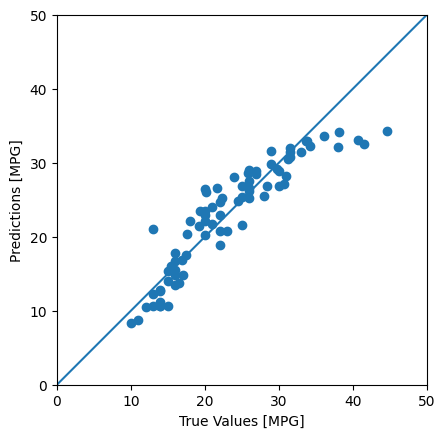

In [27]:
test_predictions = linear_model.predict(standarized_test_features)

plot_predictions(
    y_true=test_labels,
    y_pred=test_predictions,
)

In [28]:
test_results["linear_model"] = mean_squared_error(
    y_true=test_labels,
    y_pred=test_predictions,
)

test_results

{'horsepower_model': 22.026387306979775, 'linear_model': 10.022424640636533}

In [29]:
# Se agregan un término cuadrático y una interacción Weight × Horsepower para flexibilizar el modelo lineal.

train_features_flexible = train_features.copy()
test_features_flexible = test_features.copy()

for features in [train_features_flexible, test_features_flexible]:
    features["Horsepower_squared"] = features["Horsepower"] ** 2
    features["Weight_x_Horsepower"] = features["Weight"] * features["Horsepower"]

train_features_flexible[["Horsepower", "Horsepower_squared", "Weight", "Weight_x_Horsepower"]].head()

,Horsepower,Horsepower_squared,Weight,Weight_x_Horsepower
220,70.0,4900.0,1945.0,136150.0
256,100.0,10000.0,3430.0,343000.0
301,70.0,4900.0,2200.0,154000.0
193,81.0,6561.0,3012.0,243972.0
57,95.0,9025.0,2278.0,216410.0


In [30]:
# Se compara la regresión base con una especificación lineal que incluye los nuevos términos.

flexible_numeric_features = train_features_flexible.select_dtypes(include="number").columns.tolist()

flexible_features_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), flexible_numeric_features),
        ("origin", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
)

flexible_train_features = flexible_features_preprocessor.fit_transform(train_features_flexible)
flexible_test_features = flexible_features_preprocessor.transform(test_features_flexible)

linear_flexible_model = LinearRegression()
linear_flexible_model.fit(flexible_train_features, train_labels)

flexible_predictions = linear_flexible_model.predict(flexible_test_features)
test_results["linear_flexible_model"] = mean_squared_error(
    y_true=test_labels,
    y_pred=flexible_predictions,
)

test_results

{'horsepower_model': 22.026387306979775,
 'linear_model': 10.022424640636533,
 'linear_flexible_model': 7.4414035686624755}

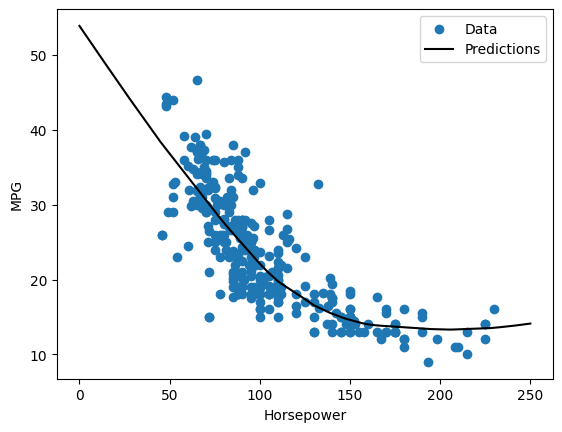

In [31]:
# Red neuronal con una sola entrada (Horsepower)

from sklearn.neural_network import MLPRegressor

mlp_horsepower = MLPRegressor(
    max_iter=10000,
    hidden_layer_sizes=(64, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    validation_fraction=0.2,
    early_stopping=True,
    random_state=0,
)
mlp_horsepower.fit(standarized_train_horsepower, train_labels)

y = mlp_horsepower.predict(scaled_x)
plot_horsepower(x, y)

In [32]:
y_pred = mlp_horsepower.predict(standarized_test_horsepower)

test_results["mlp_horsepower"] = mean_squared_error(
    y_true=test_labels,
    y_pred=y_pred,
)

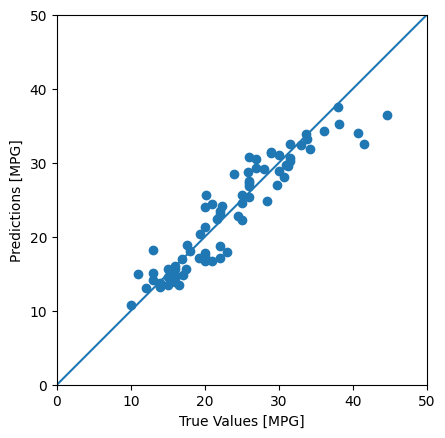

In [33]:
# Red neuronal con todas las variables

mlp = MLPRegressor(
    max_iter=10000,
    hidden_layer_sizes=(64, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    validation_fraction=0.2,
    early_stopping=True,
    random_state=0,
)

mlp.fit(standarized_train_features, train_labels)

test_predictions = mlp.predict(standarized_test_features)

plot_predictions(
    y_true=test_labels,
    y_pred=test_predictions,
)

In [34]:
test_results["mlp"] = mean_squared_error(
    y_true=test_labels,
    y_pred=test_predictions,
)

In [35]:
# Desempeño de los modelos

pd.DataFrame(test_results, index=["Mean squared error [MPG]"]).T.sort_values(
    by="Mean squared error [MPG]", ascending=False
)

,Mean squared error [MPG]
horsepower_model,22.026387
mlp_horsepower,15.599045
linear_model,10.022425
mlp,7.552758
linear_flexible_model,7.441404


In [36]:
# Se almacenan los modelos, preprocesadores y la comparación de desempeño ajustados con entrenamiento.

import os
import pickle


with open("../submission/mlp.pkl", "wb") as file:
    pickle.dump(mlp, file)

with open("../submission/features_preprocessor.pkl", "wb") as file:
    pickle.dump(features_preprocessor, file)

with open("../submission/linear_flexible_model.pkl", "wb") as file:
    pickle.dump(linear_flexible_model, file)

with open("../submission/flexible_features_preprocessor.pkl", "wb") as file:
    pickle.dump(flexible_features_preprocessor, file)

pd.DataFrame(
    {
        "model": list(test_results),
        "test_mse": list(test_results.values()),
    }
).to_csv("../submission/model_comparison.csv", index=False)

In [37]:
# Uso del modelo

import pandas as pd

dataset = pd.read_csv("../data/auto_mpg.csv")
dataset = dataset.dropna()
dataset["Origin"] = dataset["Origin"].map(
    {1: "USA", 2: "Europe", 3: "Japan"},
)
y_true = dataset.pop("MPG")

with open("../submission/mlp.pkl", "rb") as file:
    new_mlp = pickle.load(file)

with open("../submission/features_preprocessor.pkl", "rb") as file:
    new_features_preprocessor = pickle.load(file)

standarized_dataset = new_features_preprocessor.transform(dataset)
y_pred = new_mlp.predict(standarized_dataset)

mean_squared_error(
    y_true=y_true,
    y_pred=y_pred,
)

8.049348729758991